Loading asset projects/gee-personal-483416/assets/RFTrainingAsset...
Starting learning curve generation. This may take a few minutes...
Testing 10 samples per class (40 total rows)...
   Accuracy: 0.9525
Testing 50 samples per class (200 total rows)...
   Accuracy: 0.9675
Testing 100 samples per class (400 total rows)...
   Accuracy: 0.9694
Testing 500 samples per class (2000 total rows)...
   Accuracy: 0.9811
Testing 1000 samples per class (4000 total rows)...
   Accuracy: 0.9893
Testing 2500 samples per class (10000 total rows)...
   Accuracy: 0.9924
Testing 5000 samples per class (20000 total rows)...
   Accuracy: 0.9951
Testing 10000 samples per class (40000 total rows)...
   Accuracy: 0.9956
Testing 15000 samples per class (60000 total rows)...
   Accuracy: 0.9963
Testing 20000 samples per class (80000 total rows)...
   Accuracy: 0.9961
Testing 25000 samples per class (100000 total rows)...
   Accuracy: 0.9966
Testing 30000 samples per class (120000 total rows)...
   Accuracy: 0.9

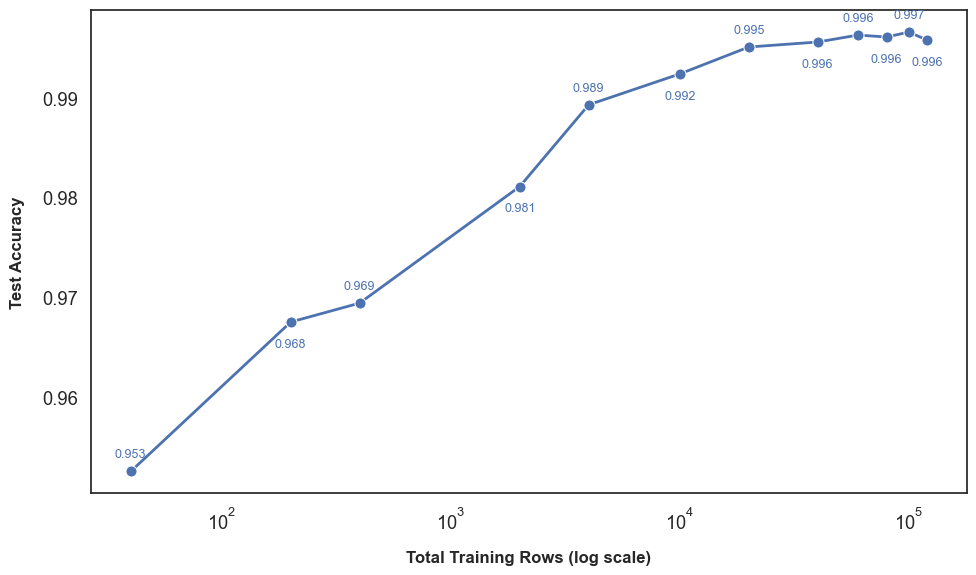

In [1]:
import ee
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Earth Engine
project_id = 'gee-personal-483416'
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 1. Constants and Hyperparameters
RANDOM_SEED = 12
ASSET_ID = "projects/gee-personal-483416/assets/RFTrainingAsset"
features = ["red", "green", "blue", "nir", "swir1", "swir2", "sensor"]
target = "class_id"
specific_class_ids = [1, 2, 3, 4]

best_params = {
    'numberOfTrees': 198, 
    'variablesPerSplit': 3, 
    'minLeafPopulation': 5, 
    'bagFraction': 0.9428329774159232, 
    'seed': RANDOM_SEED
}

# 2. Load and Split Data
print(f"Loading asset {ASSET_ID}...")
raw_data = ee.FeatureCollection(ASSET_ID)

data_with_folds = raw_data.randomColumn(columnName='fold_rand', seed=RANDOM_SEED)

# Train pool (80%) and Test pool (20%)
train_pool = data_with_folds.filter(ee.Filter.lt('fold_rand', 0.8))
test_pool = data_with_folds.filter(ee.Filter.gte('fold_rand', 0.8))

# Lock in a static, manageable test set for evaluation (e.g., 2500 per class = 10,000 total)
# This prevents GEE timeouts during the loop
fixed_test_subsets = []
for class_id in specific_class_ids:
    class_test = test_pool.filter(ee.Filter.eq(target, class_id))\
        .randomColumn('test_rand', seed=RANDOM_SEED)\
        .sort('test_rand')\
        .limit(2500)
    fixed_test_subsets.append(class_test)

fixed_test_set = fixed_test_subsets[0]
for i in range(1, len(fixed_test_subsets)):
    fixed_test_set = fixed_test_set.merge(fixed_test_subsets[i])

# 3. Define the Sample Sizes to Test (Number of samples PER CLASS)
# This will test total dataset sizes of: 400, 2000, 4000, 10000, 20000, 40000, 80000
sample_sizes = [10, 50, 100, 500, 1000, 2500, 5000, 10000, 15000, 20000, 25000, 30000]
accuracies = []

print("Starting learning curve generation. This may take a few minutes...")

# 4. Loop Through Sizes, Train, and Evaluate
for size in sample_sizes:
    print(f"Testing {size} samples per class ({size * 4} total rows)...")
    
    # Create the stratified training subset for this size
    stratified_train_subsets = []
    for class_id in specific_class_ids:
        class_train = train_pool.filter(ee.Filter.eq(target, class_id))\
            .randomColumn('train_rand', seed=RANDOM_SEED)\
            .sort('train_rand')\
            .limit(size)
        stratified_train_subsets.append(class_train)
        
    current_train_set = stratified_train_subsets[0]
    for i in range(1, len(stratified_train_subsets)):
        current_train_set = current_train_set.merge(stratified_train_subsets[i])
        
    # Train the classifier
    classifier = ee.Classifier.smileRandomForest(**best_params)\
        .train(
            features=current_train_set,
            classProperty=target,
            inputProperties=features
        )
        
    # Classify the fixed test set
    validated = fixed_test_set.classify(classifier)
    
    # Calculate accuracy and pull to local machine
    accuracy = validated.errorMatrix(target, 'classification').accuracy().getInfo()
    accuracies.append(accuracy)
    
    print(f"   Accuracy: {accuracy:.4f}")

# 5. Plot the Results
total_rows = [size * 4 for size in sample_sizes]

sns.set_context('paper')
sns.set_theme(style="white", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    x=total_rows,
    y=accuracies,
    marker='o',
    linewidth=2,
    markersize=8,
    color='b',
    ax=ax
)

for i, (x, y) in enumerate(zip(total_rows, accuracies)):
    offset = 10 if i % 2 == 0 else -18
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", 
                xytext=(0, offset), ha='center', fontsize=9, color='b')

ax.set_xscale('log')
ax.set_xlabel('Total Training Rows (log scale)', fontsize=12, weight='bold', labelpad=12)
ax.set_ylabel('Test Accuracy', fontsize=12, weight='bold', labelpad=12)

plt.tight_layout()
plt.savefig('../../figures/MLfigures/learning_curve_log.png', dpi=300, bbox_inches='tight')
plt.show()

Loading asset projects/gee-personal-483416/assets/RFTrainingAsset...
Starting learning curve generation. This may take a few minutes...
Testing 10 samples per class (40 total rows)...
   Accuracy: 0.9525
Testing 50 samples per class (200 total rows)...
   Accuracy: 0.9675
Testing 100 samples per class (400 total rows)...
   Accuracy: 0.9694
Testing 500 samples per class (2000 total rows)...
   Accuracy: 0.9811
Testing 1000 samples per class (4000 total rows)...
   Accuracy: 0.9893
Testing 2500 samples per class (10000 total rows)...
   Accuracy: 0.9924
Testing 5000 samples per class (20000 total rows)...
   Accuracy: 0.9951
Testing 10000 samples per class (40000 total rows)...
   Accuracy: 0.9956
Testing 15000 samples per class (60000 total rows)...
   Accuracy: 0.9963
Testing 20000 samples per class (80000 total rows)...
   Accuracy: 0.9961
Testing 25000 samples per class (100000 total rows)...
   Accuracy: 0.9966
Testing 30000 samples per class (120000 total rows)...
   Accuracy: 0.9

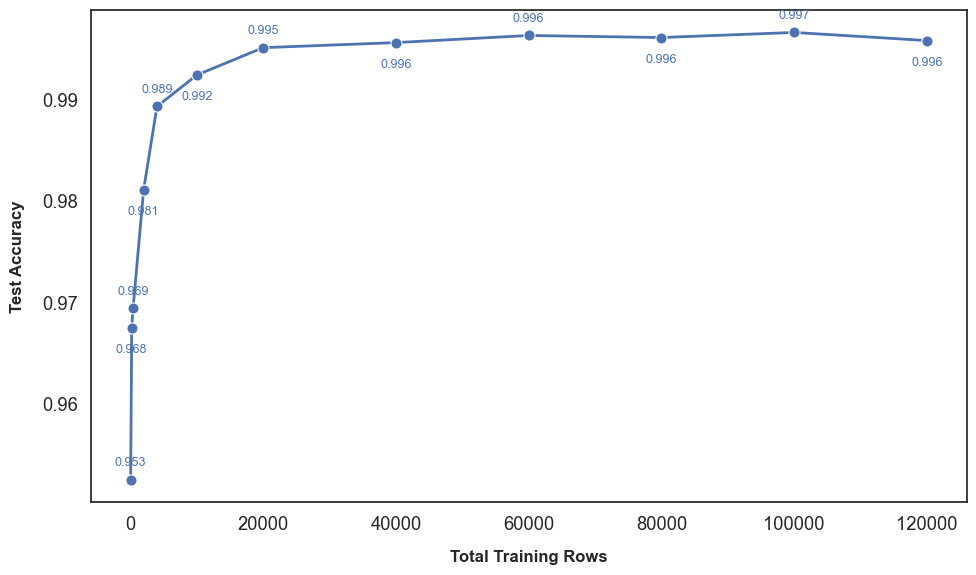

In [3]:
import ee
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Earth Engine
project_id = 'gee-personal-483416'
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

# 1. Constants and Hyperparameters
RANDOM_SEED = 12
ASSET_ID = "projects/gee-personal-483416/assets/RFTrainingAsset"
features = ["red", "green", "blue", "nir", "swir1", "swir2", "sensor"]
target = "class_id"
specific_class_ids = [1, 2, 3, 4]

best_params = {
    'numberOfTrees': 198, 
    'variablesPerSplit': 3, 
    'minLeafPopulation': 5, 
    'bagFraction': 0.9428329774159232, 
    'seed': RANDOM_SEED
}

# 2. Load and Split Data
print(f"Loading asset {ASSET_ID}...")
raw_data = ee.FeatureCollection(ASSET_ID)

data_with_folds = raw_data.randomColumn(columnName='fold_rand', seed=RANDOM_SEED)

# Train pool (80%) and Test pool (20%)
train_pool = data_with_folds.filter(ee.Filter.lt('fold_rand', 0.8))
test_pool = data_with_folds.filter(ee.Filter.gte('fold_rand', 0.8))

# Lock in a static, manageable test set for evaluation (e.g., 2500 per class = 10,000 total)
# This prevents GEE timeouts during the loop
fixed_test_subsets = []
for class_id in specific_class_ids:
    class_test = test_pool.filter(ee.Filter.eq(target, class_id))\
        .randomColumn('test_rand', seed=RANDOM_SEED)\
        .sort('test_rand')\
        .limit(2500)
    fixed_test_subsets.append(class_test)

fixed_test_set = fixed_test_subsets[0]
for i in range(1, len(fixed_test_subsets)):
    fixed_test_set = fixed_test_set.merge(fixed_test_subsets[i])

# 3. Define the Sample Sizes to Test (Number of samples PER CLASS)
# This will test total dataset sizes of: 400, 2000, 4000, 10000, 20000, 40000, 80000
sample_sizes = [10, 50, 100, 500, 1000, 2500, 5000, 10000, 15000, 20000, 25000, 30000]
accuracies = []

print("Starting learning curve generation. This may take a few minutes...")

# 4. Loop Through Sizes, Train, and Evaluate
for size in sample_sizes:
    print(f"Testing {size} samples per class ({size * 4} total rows)...")
    
    # Create the stratified training subset for this size
    stratified_train_subsets = []
    for class_id in specific_class_ids:
        class_train = train_pool.filter(ee.Filter.eq(target, class_id))\
            .randomColumn('train_rand', seed=RANDOM_SEED)\
            .sort('train_rand')\
            .limit(size)
        stratified_train_subsets.append(class_train)
        
    current_train_set = stratified_train_subsets[0]
    for i in range(1, len(stratified_train_subsets)):
        current_train_set = current_train_set.merge(stratified_train_subsets[i])
        
    # Train the classifier
    classifier = ee.Classifier.smileRandomForest(**best_params)\
        .train(
            features=current_train_set,
            classProperty=target,
            inputProperties=features
        )
        
    # Classify the fixed test set
    validated = fixed_test_set.classify(classifier)
    
    # Calculate accuracy and pull to local machine
    accuracy = validated.errorMatrix(target, 'classification').accuracy().getInfo()
    accuracies.append(accuracy)
    
    print(f"   Accuracy: {accuracy:.4f}")

# 5. Plot the Results
total_rows = [size * 4 for size in sample_sizes]

sns.set_context('paper')
sns.set_theme(style="white", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    x=total_rows,
    y=accuracies,
    marker='o',
    linewidth=2,
    markersize=8,
    color='b',
    ax=ax
)

for i, (x, y) in enumerate(zip(total_rows, accuracies)):
    offset = 10 if i % 2 == 0 else -18
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", 
                xytext=(0, offset), ha='center', fontsize=9, color='b')

ax.set_xlabel('Total Training Rows', fontsize=12, weight='bold', labelpad=12)
ax.set_ylabel('Test Accuracy', fontsize=12, weight='bold', labelpad=12)

plt.tight_layout()
plt.savefig('../../figures/MLfigures/learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import ee
import json

# Initialize Earth Engine
project_id = 'gee-personal-483416'
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

RANDOM_SEED      = 12
ASSET_ID         = "projects/gee-personal-483416/assets/RFTrainingAsset"
features         = ["red", "green", "blue", "nir", "swir1", "swir2", "sensor"]
target           = "class_id"
specific_class_ids = [1, 2, 3, 4]

best_params = {
    'numberOfTrees':      198,
    'variablesPerSplit':  3,
    'minLeafPopulation':  5,
    'bagFraction':        0.9428329774159232,
    'seed':               RANDOM_SEED
}

raw_data        = ee.FeatureCollection(ASSET_ID)
data_with_folds = raw_data.randomColumn(columnName='fold_rand', seed=RANDOM_SEED)
train_pool      = data_with_folds.filter(ee.Filter.lt('fold_rand', 0.8))
test_pool       = data_with_folds.filter(ee.Filter.gte('fold_rand', 0.8))

fixed_test_subsets = []
for class_id in specific_class_ids:
    fixed_test_subsets.append(
        test_pool.filter(ee.Filter.eq(target, class_id))
                 .randomColumn('test_rand', seed=RANDOM_SEED)
                 .sort('test_rand').limit(2500)
    )
fixed_test_set = fixed_test_subsets[0]
for i in range(1, len(fixed_test_subsets)):
    fixed_test_set = fixed_test_set.merge(fixed_test_subsets[i])

sample_sizes = [10, 50, 100, 500, 1000, 2500, 5000, 10000, 15000, 20000, 25000, 30000]
accuracies   = []

print("Starting learning curve generation...")
for size in sample_sizes:
    print(f"  {size} samples/class ({size*4} total)...")
    subsets = []
    for class_id in specific_class_ids:
        subsets.append(
            train_pool.filter(ee.Filter.eq(target, class_id))
                      .randomColumn('train_rand', seed=RANDOM_SEED)
                      .sort('train_rand').limit(size)
        )
    current_train = subsets[0]
    for i in range(1, len(subsets)):
        current_train = current_train.merge(subsets[i])

    classifier = ee.Classifier.smileRandomForest(**best_params).train(
        features=current_train, classProperty=target, inputProperties=features
    )
    accuracy = (fixed_test_set.classify(classifier)
                              .errorMatrix(target, 'classification')
                              .accuracy().getInfo())
    accuracies.append(accuracy)
    print(f"    → {accuracy:.4f}")

# ── Save so the plot block never needs to rerun training ──
results = {'sample_sizes': sample_sizes, 'accuracies': accuracies}
with open('../../figures/MLfigures/learning_curve_results.json', 'w') as f:
    json.dump(results, f)
print("Saved to learning_curve_results.json")

Starting learning curve generation...
  10 samples/class (40 total)...
    → 0.9525
  50 samples/class (200 total)...
    → 0.9675
  100 samples/class (400 total)...
    → 0.9694
  500 samples/class (2000 total)...
    → 0.9811
  1000 samples/class (4000 total)...
    → 0.9893
  2500 samples/class (10000 total)...
    → 0.9924
  5000 samples/class (20000 total)...
    → 0.9951
  10000 samples/class (40000 total)...
    → 0.9956
  15000 samples/class (60000 total)...
    → 0.9963
  20000 samples/class (80000 total)...
    → 0.9961
  25000 samples/class (100000 total)...
    → 0.9966
  30000 samples/class (120000 total)...
    → 0.9958
Saved to learning_curve_results.json


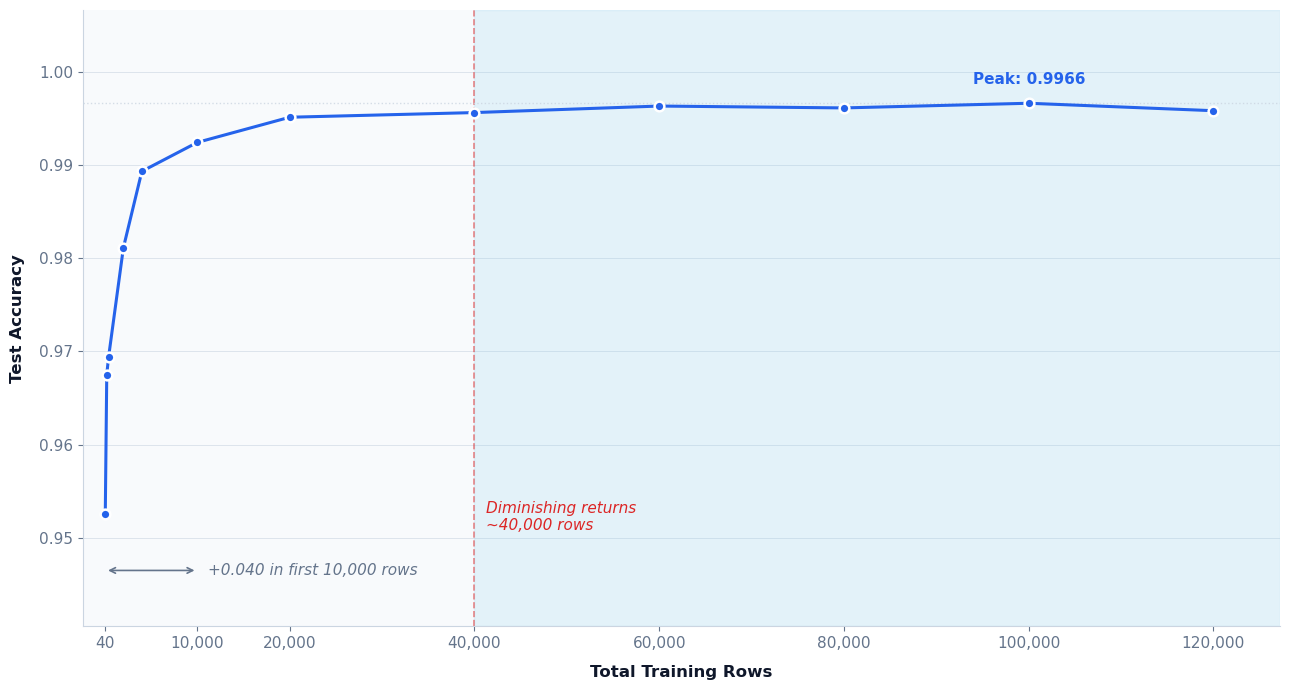

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline

# ── Load saved results ──
with open('../../figures/MLfigures/learning_curve_results.json', 'r') as f:
    results = json.load(f)

sample_sizes = results['sample_sizes'
                       ]
accuracies   = results['accuracies']
total_rows   = [s * 4 for s in sample_sizes]

# ── Style constants (matching rest of paper) ──

LIGHT_BG       = '#FFFFFF'
PANEL_BG       = '#F8FAFC'
GRID_COLOR     = '#CBD5E1'
TEXT_COLOR     = '#0F172A'
SUBTEXT_COLOR  = '#64748B'
LINE_COLOR     = '#2563EB'
FILL_COLOR     = '#89CFF0'
ANNOT_COLOR    = '#DC2626'

plt.rcParams.update({
    'text.color': TEXT_COLOR,
    'axes.labelcolor': TEXT_COLOR,
    'xtick.color': SUBTEXT_COLOR,
    'ytick.color': SUBTEXT_COLOR,
    'axes.edgecolor': GRID_COLOR,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

x = np.array(total_rows)
y = np.array(accuracies)

# ── Smooth spline for fill (visual only — dots show true values) ──
x_smooth = np.linspace(x.min(), x.max(), 400)
spline   = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# ── Derive some annotation points ──
gain_early = y[5] - y[0]          # accuracy gain in first 2000 rows
saturation_idx = next(          # first index where improvement < 0.001
    i for i in range(1, len(y)) if abs(y[i] - y[i-1]) < 0.001
)
saturation_x = x[saturation_idx]
saturation_y = y[saturation_idx]
peak_idx = int(np.argmax(y))
peak_x, peak_y = x[peak_idx], y[peak_idx]

# ── Figure ──
fig, ax = plt.subplots(figsize=(13, 7), facecolor=LIGHT_BG)
ax.set_facecolor(PANEL_BG)

# ── ADD: shaded plateau rectangle ──
ax.axvspan(saturation_x, x.max() * 1.06,
           color=FILL_COLOR, alpha=0.18, zorder=1,
           label='Plateau region')

# Vertical saturation marker
ax.axvline(saturation_x, color=ANNOT_COLOR, lw=1.2, ls='--', alpha=0.55, zorder=2)
ax.text(saturation_x + x.max() * 0.01, y.min() - 0.002,
        f'Diminishing returns\n~{saturation_x:,} rows',
        fontsize=11, color=ANNOT_COLOR, va='bottom', style='italic')

# ── REPLACE the peak axhline + text with this ──
ax.axhline(peak_y, color=GRID_COLOR, lw=1.0, ls=':', zorder=2, alpha=0.8)
ax.text(peak_x, peak_y + (y.max() - y.min()) * 0.04,
        f'Peak: {peak_y:.4f}',
        fontsize=11, color=LINE_COLOR, va='bottom', ha='center',
        fontweight='bold', zorder=7)

# True data points
ax.plot(x, y, color=LINE_COLOR, lw=2.2, marker='o', ms=7,
        mec='white', mew=1.8, zorder=5, solid_capstyle='round',
        label='Test accuracy')

# # ── Per-point annotations — staggered to avoid overlap ──
# for i, (xi, yi) in enumerate(zip(x, y)):
#     # alternate above/below, push first few up more since curve is steep
#     offset = 12 if i % 2 == 0 else -16
#     if i < 4:
#         offset = abs(offset) + 4    # always above in steep region
#     ax.annotate(
#         f'{yi:.4f}',
#         xy=(xi, yi),
#         xytext=(0, offset), textcoords='offset points',
#         fontsize=7.5, color=LINE_COLOR, ha='center',
#         fontweight='bold', zorder=6,
#     )

# ── Early gain bracket — horizontal arrow at y=0.955 ──
bracket_y = y.min() - 0.006
arrow_x_start = x[0]
arrow_x_end   = x[5]
ax.annotate('', xy=(arrow_x_end, bracket_y), xytext=(arrow_x_start, bracket_y),
            arrowprops=dict(arrowstyle='<->', color=SUBTEXT_COLOR,
                            lw=1.2, mutation_scale=10))
ax.text(arrow_x_end + x.max() * 0.01, bracket_y,
        f'+{gain_early:.3f} in first {x[5]:,} rows',
        fontsize=11, color=SUBTEXT_COLOR, va='center', ha='left', style='italic')

# ── Axes ──
ax.set_xlim(-x.max() * 0.02, x.max() * 1.06)
ax.set_ylim(y.min() - 0.012, y.max() + 0.010)
ax.set_xlabel('Total Training Rows', fontsize=12, weight='bold', labelpad=10)
ax.set_ylabel('Test Accuracy', fontsize=12, weight='bold', labelpad=10)
ax.yaxis.grid(True, color=GRID_COLOR, lw=0.6, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# x-ticks at actual data points
custom_ticks  = [40, 10000, 20000, 40000, 60000, 80000, 100000, 120000]
custom_labels = [f'{v:,}' for v in custom_ticks]

ax.set_xticks(custom_ticks)
ax.set_xticklabels(custom_labels, ha='center', fontsize=11)

# save and show

plt.tight_layout()
plt.savefig('../../figures/MLfigures/learning_curve.png',
            dpi=300, bbox_inches='tight', facecolor=LIGHT_BG)
plt.show()

plt.rcParams.update(plt.rcParamsDefault)